In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from astropy.io import fits
from utils import *
from ccd_simulation import *
from tqdm.autonotebook import tqdm


/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_53166/2192590687.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
from collections import Counter
image_dir_search = 'proc/*.fits'
temperatures = []


for image in glob.glob(image_dir_search):
    temp = re.findall('_\d+k',image)[0][1:-1]
    if 'dtph' not in image:
        continue
    # if temp not in temperatures:
   
    temperatures.append(temp)
temperatures_strs = np.array(temperatures)

print(Counter(temperatures_strs))
# temperatures = np.unique(np.sort(temperatures))
temps = np.sort(np.array([int(t) for t in temperatures_strs]))

Counter()


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/var/folders/k8/_jhxw6sx2gj8wjzbhc789q540000gn/T/ipykernel_53166/736742656.py:7: SyntaxWarning: invalid escape sequence '\d'
  temp = re.findall('_\d+k',image)[0][1:-1]


In [3]:
from dipole import *
import pickle
goodQuads = [0,1,2,3]
image_dir = 'proc/'
test_temps = temperatures


try:
    with open('dipole_coord_list.pkl','rb') as infile:
        full_dipole_coord_list = pickle.load(infile)
except FileNotFoundError:
    full_dipole_coord_list = getDipoleList2(image_dir,test_temps,goodQuads)
    with open('dipole_coord_list.pkl','wb') as outfile:
        pickle.dump(full_dipole_coord_list,outfile)

        
try:
    with open('dipole_spectra.pkl','rb') as infile:
        dipole_spectra = pickle.load(infile)
except FileNotFoundError:
    dipole_spectra = getDipoleSpectra2(image_dir,goodQuads,full_dipole_coord_list)
    with open('dipole_spectra.pkl','wb') as outfile:
        pickle.dump(dipole_spectra,outfile)

useIntensityErr = True
wellBehavedThreshold = 4
threshold_str = f'_{wellBehavedThreshold}'
intensity_str = '_err' if useIntensityErr else ''
try:
    with open(f'fit_dipole_spectra{intensity_str}{threshold_str}.pkl','rb') as infile:
        fit_dipole_spectra = pickle.load(infile)

except FileNotFoundError:
    fit_dipole_spectra = fitTrapIntensity(dipole_spectra,useIntensityErr=useIntensityErr,wellBehavedThreshold=wellBehavedThreshold)
    with open(f'fit_dipole_spectra{intensity_str}{threshold_str}.pkl','wb') as outfile:
        pickle.dump(fit_dipole_spectra,outfile)

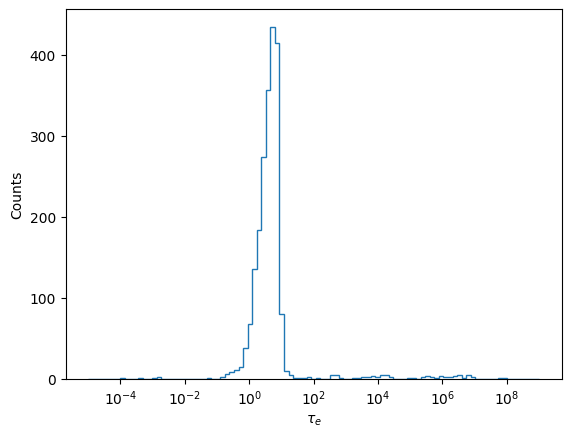

In [4]:
tau_at_135s = []
for q in [0,1,2,3]:
    
    dpkeys = list(fit_dipole_spectra[q])
    for i in range(len(dpkeys)):
        
        # dpkeys = list(fit1_dipole_spectra[q])
        # dp = random.choice(dpkeys)
        dp = dpkeys[i]
        if type(dp) != tuple:
            continue
        testdp = fit_dipole_spectra[q][dp]
        if testdp['WellBehavedTrap'] and not testdp['EnergyFitFailed']:
            testdpfit = testdp['EnergyFitInfo']

            # p_value = testdpfit['p_value'] 
            # chi_squared = testdpfit['chi2']
            # r2 = testdpfit['r_squared']

            # pvals.append(p_value)
            # chi2s.append(chi_squared)
            # r2s.append(r2)
            # red_chi2s.append( testdpfit['reduced_chi2'])


            # fit_is_good = chi_squared < 100

            # fit_is_good = p_value < 0.05
            fit_is_good = testdp["GoodEnergyFit"]
            # fit_is_good = fit_is_good and 
            # maxtau = np.max(testdpfit['taus'])
            # maxtaus.append(maxtau)
            # fit_is_good = fit_is_good
            # fit_is_good = True


            if fit_is_good:
                cs = testdpfit['BestFitCrossSection']
                cserr = testdpfit['BestFitCrossSectionErr']
                e = testdpfit['BestFitEnergy']
                e_err = testdpfit['BestFitEnergyErr']

                 # temperatures = np.linspace(120,180,100)
                logtau_at_135 = log_energy_cross_section(135,e,np.log(cs))

                tau_at_135 = np.exp(logtau_at_135)
                tau_at_135s.append(tau_at_135)
              

                
                  
bins = np.geomspace(1e-5,1e9,100)
tau_at_135s = np.array(tau_at_135s)  
hist,bin_edges = np.histogram(tau_at_135s,bins)          
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
# stuff =  plt.hist(tau_at_135s,bins=bins)
plt.stairs(hist,bins)
plt.xlabel("$\\tau_e$")
plt.xscale('log')
plt.ylabel("Counts")
plt.show()
plt.close()


len(hist),len(bin_edges),len(bin_centers)
tau_weights = hist
tau_values = bin_centers

In [19]:
tau_weights

array([  0,   0,   0,   0,   0,   0,   0,   1,   0,   0,   0,   1,   0,
         0,   1,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         1,   0,   0,   2,   6,   8,  11,  14,  38,  68, 136, 184, 274,
       357, 435, 415,  80,  10,   5,   1,   1,   1,   2,   0,   1,   0,
         0,   4,   4,   1,   0,   0,   1,   1,   2,   2,   3,   2,   5,
         4,   2,   0,   0,   0,   1,   1,   0,   2,   3,   2,   1,   3,
         2,   2,   3,   4,   1,   4,   2,   0,   0,   0,   0,   0,   1,
         1,   0,   0,   0,   0,   0,   0,   0])

In [5]:


UL_expdep = 8.19e-5 #e / pix / day

UR_expdep = 4.36e-5 #e / pix / day

LL_expdep = 6.88e-5 #e / pix / day

LR_expdep = 8.23e-5 #e / pix / day

UL_expindep = 12.23e-5 #e / superpix / image

UR_expindep = 9.94e-5 #e / superpix / image

LL_expindep = 7.53e-5 #e / superpix / image

LR_expindep = 6.52e-5 #e / superpix / day


#maybe just use lowest for now?
exp_dep_rate = UR_expdep / (24 * 3600) #e / pix / s

exp = 72000 # s



exp_indep_rate = UR_expindep/ 32 #e / pix / image
npix = (6144)* (1024)
npix_per_quad = npix / 4
print(npix_per_quad)

print(6144/2,1024/2)
exp_indep_events = exp_indep_rate * npix_per_quad
exp_indep_events = np.round(exp_indep_events)

exp_dep_events = exp_dep_rate * exp * npix

exp_dep_events = np.round(exp_dep_events)

print(exp_dep_events)
print(exp_indep_events)

n_singlee_events = int(exp_dep_events + exp_indep_events)

n_singlee_events = np.random.poisson(n_singlee_events)

print(f'Injecting {n_singlee_events} 1e events')
#now generate fake image
file = 'minos_image/proc_corr_proc_skp_72000secs_exp_run10_NSAMP_300_36.fits'

q0 = get_qdata(file,0)
print(q0.shape)

q0 =approximate_electronize(q0,400)
q0_blank= transplant_clusters(q0.T, target_shape=(512, 3072),count_threshold=20, max_aspect_ratio=3.0,radius=50)


q0_fake = inject_single_e(q0_blank, n_events=n_singlee_events, intensity=1)

trap_density = 5171 / (npix)


1572864.0
3072.0 512.0
229.0
5.0
Injecting 240 1e events
(3100, 470)


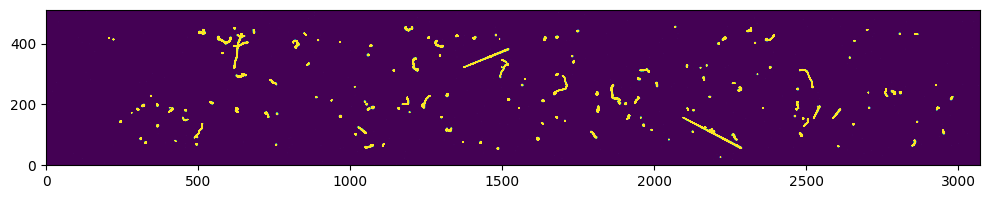

In [6]:

# Assuming 'image_array' is your simulated 2D No-Trap image
plt.figure(figsize=(10, 10))
# Restrict vmax so the 1e- events and background noise are brightly visible
plt.imshow(q0_fake, cmap='viridis', origin='lower', vmin=0, vmax=5) 
# plt.colorbar(label='Electrons')
plt.tight_layout()
plt.savefig('simulated_ccd_image.png', dpi=300)
plt.show()
plt.close()

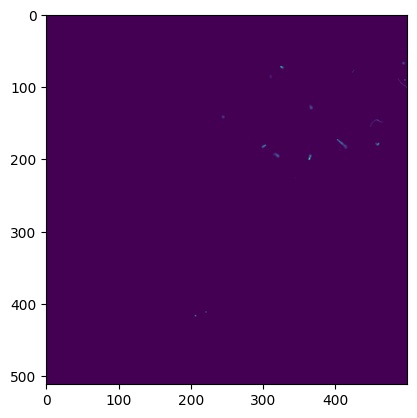

In [7]:
plt.imshow(q0_fake[:,:500])

In [20]:




# snolab_dir = '/data/analyses/snolab_run1/'
snolab_dir = './snolab_image/'

file = 'proc_corr_proc_skp_sensei_2023-02-14_135K_run7_commissioning_NROW520_NBINROW1_NCOL3200_NBINCOL1_EXPOSURE72000_CLEAR10800_5_83.fits'
with fits.open(snolab_dir +file) as hdul:
    q = hdul[0]
    header = q.header
    print(list(header.keys()))
    nrow=header['NROW']
    ncol=header['NCOL']
    exposure=header['EXPOSURE']
    nsamp=header['NSAMP']
    delayH=header['HIERARCH DELAY_H_OVERLAP']
    delayRG=header['HIERARCH DELAY_RG_WIDTH']
    delayIped=header['HIERARCH DELAY_INTEG_PED']
    delaySW=header['HIERARCH DELAY_SWHIGH']
    delayIsig=header['HIERARCH DELAY_INTEG_SIG']
    delayOG=header['HIERARCH DELAY_OG_LOW']
    delayDG=header['HIERARCH DELAY_DG_LOW']


    
#     print(list(q.header.keys()))
#     print(q.header['DATESTART'])
#     print(q.header['EXPOSURE'])

#     dte_start = q.header['DATESTART']
#     dte_end = q.header['DATEEND']
#     t = Time([dte_start,dte_end], format='isot')
#     readout_time = t.jd[1] - t.jd[0]
#     print(readout_time * 24 * 3600)
#     readout_time =readout_time * 24 * 3600
# # singleReadTime = smask.readout_time - exp
# # seconds_per_row = (singleReadTime)/nRow
# # seconds_per_pixel = seconds_per_row/nCol

# singleReadTime = readout_time - 72000

# seconds_per_row = (singleReadTime)/nRow
# seconds_per_pixel = seconds_per_row/nCol
tpix=pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG) / 15e6
tpix_vertical=pixel_time_vertical(nsamp,ncol, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG,delayDG)/15e6
tpix_vertical


['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2', 'EXTEND', 'COMMENT', 'COMMENT', 'CCDNCOL', 'CCDNPRES', 'CCDNROW', 'EXPOSURE', 'NBINCOL', 'NBINROW', 'NCOL', 'NROW', 'NSAMP', 'SKIPCOL', 'SKIPROW', 'TOG_VDD', 'TOG_VR', 'DELAY_H_OVERLAP', 'DELAY_INTEG_PED', 'DELAY_INTEG_SIG', 'DELAY_RG_WIDTH', 'DELAY_SWHIGH', 'DELAY_V_OVERLAP', 'DELAY_DG_LOW', 'DELAY_EXPOSE', 'DELAY_OG_LOW', 'V1AH', 'V1AL', 'V1BH', 'V1BL', 'V2CH', 'V2CL', 'V3AH', 'V3AL', 'V3BH', 'V3BL', 'H1AH', 'H1AL', 'H1BH', 'H1BL', 'H2CH', 'H2CL', 'H3AH', 'H3AL', 'H3BH', 'H3BL', 'SWAH', 'SWAL', 'SWBH', 'SWBL', 'RGAH', 'RGAL', 'RGBH', 'RGBL', 'OGAH', 'OGAL', 'OGBH', 'OGBL', 'DGAH', 'DGAL', 'DGBH', 'DGBL', 'TGAH', 'TGAL', 'TGBH', 'TGBL', 'LDAC_N', 'CLR_N', 'RESET_N', 'SW_EN', 'VDRAIN', 'VDD', 'VR', 'VSUB', 'VDD_SW', 'VDRAIN_SW', 'VSUB_SW', 'VSUB_LOAD_SW', 'VSUB_RDIV_SW', 'VR_SW', 'P15V_SW', 'M15V_SW', 'PACKSOURCE', 'PACKSTART', 'TESTPTRNA', 'TESTPTRNB', 'TESTPTRNC', 'TESTPTRND', 'CALSTART', 'CALADONE', 'CALBDONE', 'CALCDONE', 'CALDDONE'

49.09696

(470, 3100)


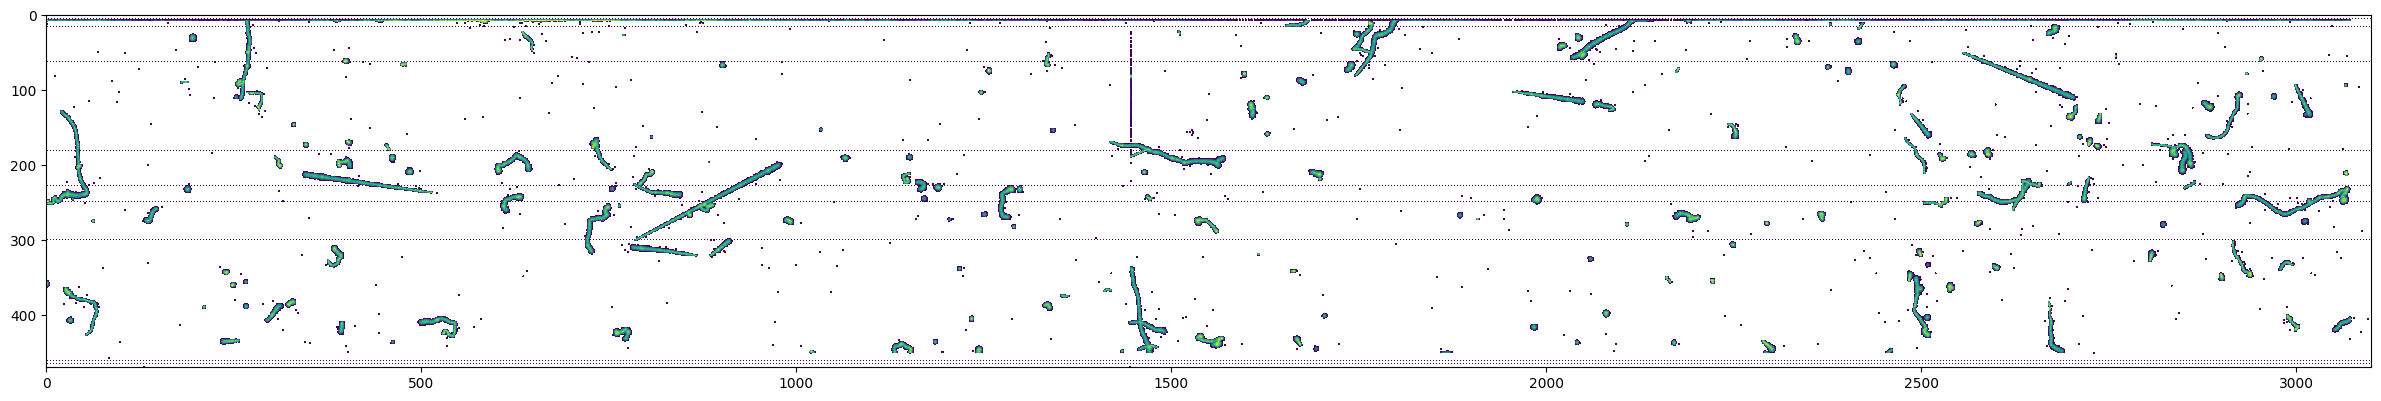

In [9]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(30,20))
image = get_qdata('minos_image/proc_corr_proc_skp_72000secs_exp_run10_NSAMP_300_36.fits',0).T
image = approximate_electronize(image,400)
plt.imshow(image,norm=LogNorm(1,vmax=image.max()))
print(image.shape)

In [10]:
CCDTest = CCD(tpix,tpix_vertical,tau_weights,tau_values)
CCDTest.take_fake_image(0,store_image=True)
CCDTest.take_fake_image(4,store_image=True)
CCDTest.take_fake_image(6,store_image=True)
CCDTest.take_fake_image(10,store_image=True)
CCDTest.take_fake_image(20,store_image=True)

CCDTest.process_run()


--- Starting Masking ---
1. Aggregating statistics using Split-Sample (A/B)...
2. Computing global hot pixel/column masks (Cross-Validation)...
3. Evaluating all mask permutations and extracting counts...
--- Post-Run Analysis Complete ---


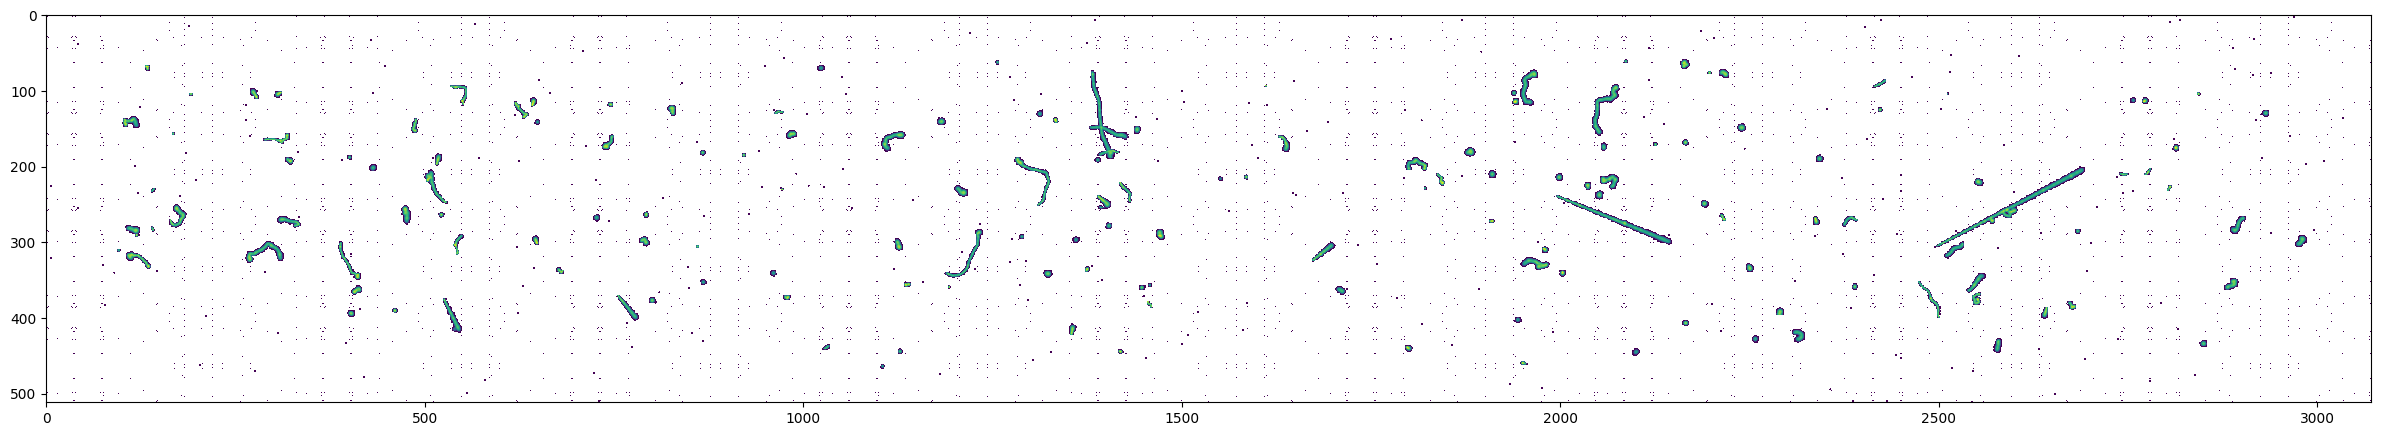

In [11]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(30,20))
image = CCDTest.no_trap_images[4]
plt.imshow(image,norm=LogNorm(1,vmax=image.max()))

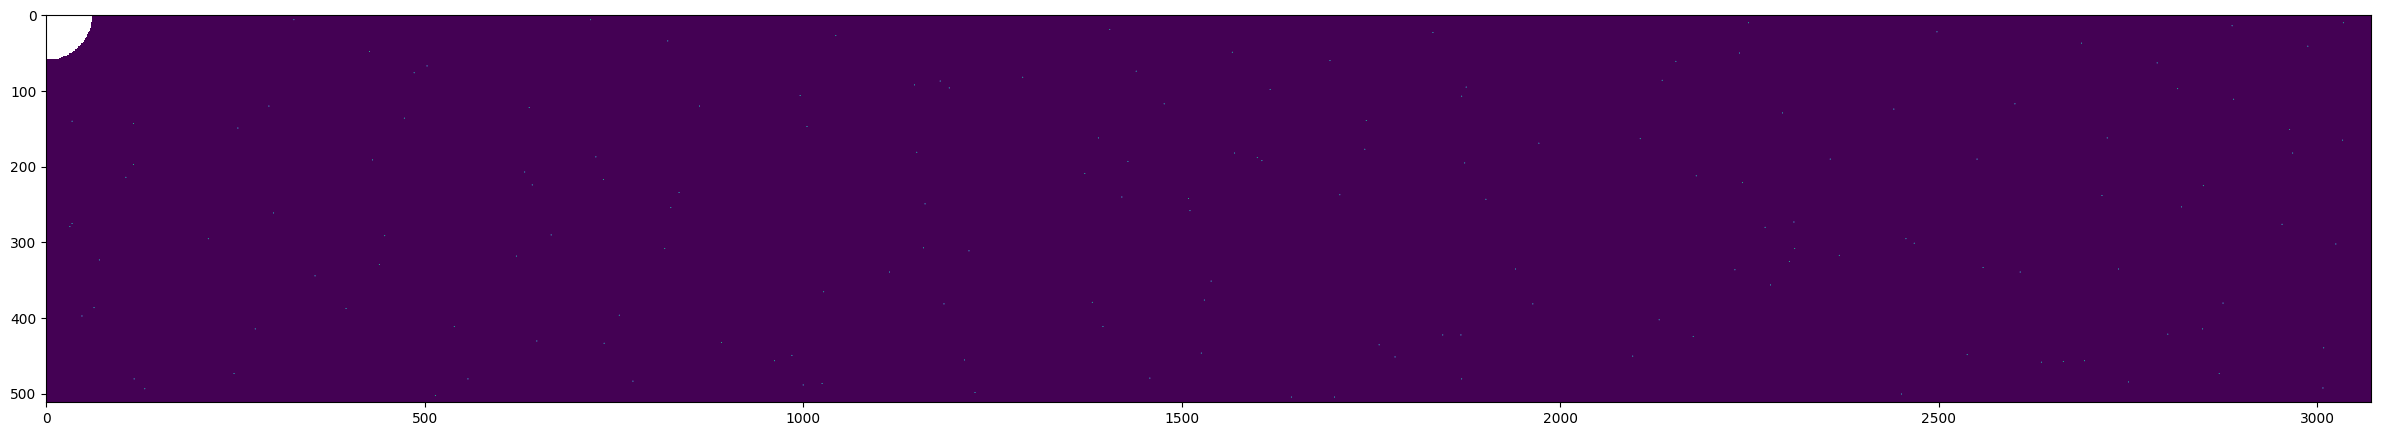

In [12]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(30,20))
image = CCDTest.no_trap_images[0]
bitmask = CCDTest.trap_bitmasks[0]
overlap_mask = (bitmask & 2 == 0)# & (bitmask & 8 > 0)
mask_image = image.copy().astype(float)
maskbits = 2 + 4
mask = bitmask & maskbits ==0
mask_image[~mask]= np.nan
# mask_image[bitma] = np.nan
plt.imshow(mask_image)

In [13]:
get_cluster(CCDTest.reconstructed_images[0],min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True),get_cluster(CCDTest.no_trap_images[0],min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)

(163, 163)

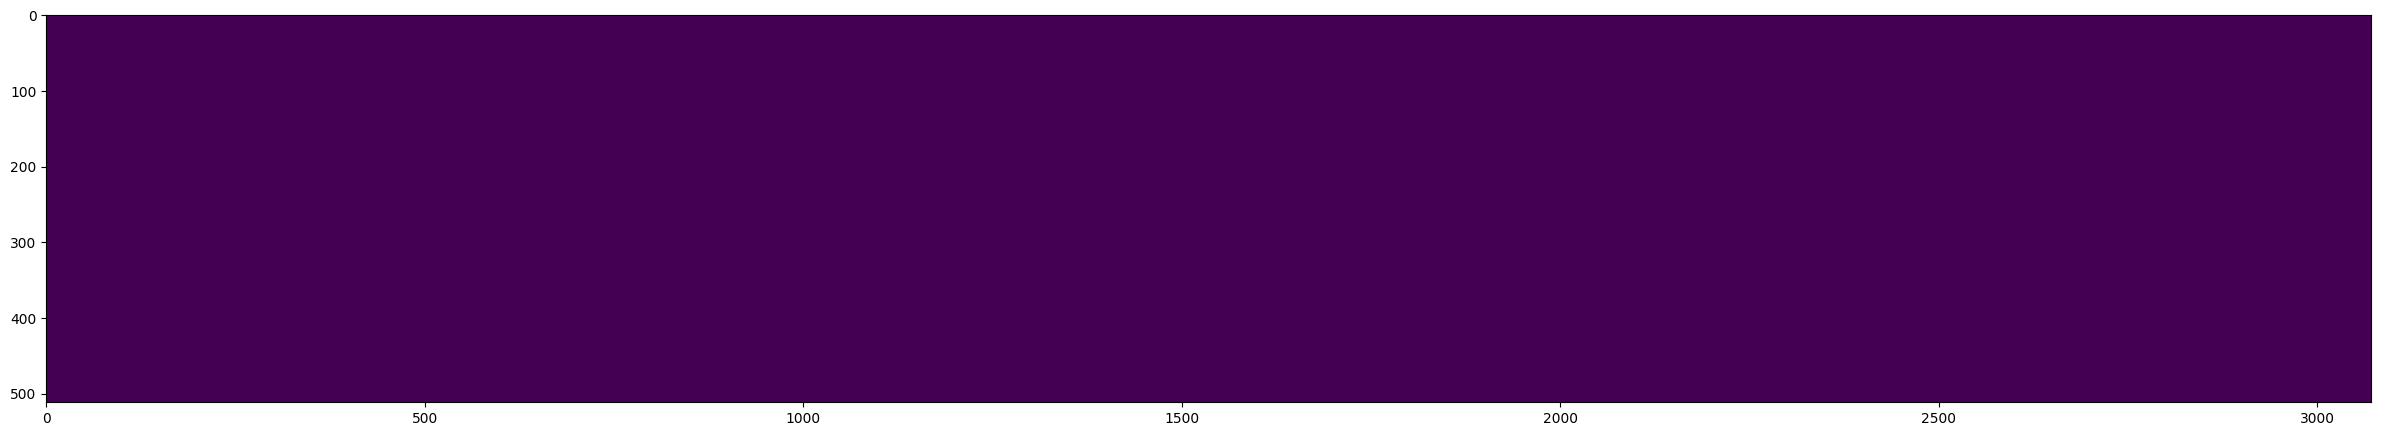

In [14]:
from matplotlib.colors import LogNorm
plt.figure(figsize=(30,20))
image = CCDTest.reconstructed_images[0]
plt.imshow(image,norm=LogNorm(1,vmax=image.max()))

In [15]:
# import pickle
# num_images = 100
# num_runs = 500
# for r in tqdm(range(num_runs)):
#     filename = f'ccd_traps_run{r}.pkl'

#     CCDTest = CCD(tpix,tpix_vertical,tau_weights,tau_values)

#     for i in tqdm(range(num_images)):
#         CCDTest.take_fake_image(0) #0h exposure
#         CCDTest.take_fake_image(4) #4h exposure
#         CCDTest.take_fake_image(6) #6h exposure
#         CCDTest.take_fake_image(10) #10h exposure
#         CCDTest.take_fake_image(20) #20h exposure
#     CCDTest.process_run()

#     CCDTest.reconstructed_images = []
#     CCDTest.no_trap_images = []
#     CCDTest.no_trap_images = []
#     CCDTest.trap_bitmasks = []
#     CCDTest.notrap_bitmasks = []
#     CCDTest.ccd_state = [] # Clear this too just in case

#     with open(filename,'wb') as f:
#         pickle.dump(CCDTest,f)
        
#     del CCDTest

#         # counts1e_notraps.append(counts_1e_og)
#         # counts1e_traps.append(counts_1e_trap)
    



In [17]:
import multiprocessing
from concurrent.futures import ProcessPoolExecutor
from tqdm.autonotebook import tqdm
import itertools
from ccd_simulation import run_single_trial

num_runs = 500
num_workers = max(1, multiprocessing.cpu_count() - 1)
num_workers = 4
print(f"Starting parallel execution with {num_workers} CPU cores...")

runconditions = 'snolab'
with ProcessPoolExecutor(max_workers=num_workers) as executor:
    # executor.map can take multiple iterables. It stops when the shortest one (range) runs out.
    # itertools.repeat() efficiently yields the exact same memory reference over and over.
    results = list(tqdm(
        executor.map(
            run_single_trial, 
            range(num_runs),                     # r (changes 0 to 499)
            itertools.repeat(tpix),              # tpix (constant)
            itertools.repeat(tpix_vertical),     # tpix_vertical (constant)
            itertools.repeat(tau_weights),       # tau_weights (constant)
            itertools.repeat(tau_values),        # tau_values (constant)
            itertools.repeat(runconditions)              # run conditions (string constant)
        ), 
        total=num_runs, 
        desc="Running Trials"
    ))


Starting parallel execution with 4 CPU cores...


Running Trials:   0%|          | 0/500 [00:00<?, ?it/s]

Using snolab run conditions, assuming 10x less high energy events
Using snolab run conditions, assuming 10x less high energy events
Using snolab run conditions, assuming 10x less high energy events
Using snolab run conditions, assuming 10x less high energy events

--- Starting Masking ---
1. Aggregating statistics using Split-Sample (A/B)...

--- Starting Masking ---
1. Aggregating statistics using Split-Sample (A/B)...

--- Starting Masking ---
1. Aggregating statistics using Split-Sample (A/B)...

--- Starting Masking ---
1. Aggregating statistics using Split-Sample (A/B)...
2. Computing global hot pixel/column masks (Cross-Validation)...
2. Computing global hot pixel/column masks (Cross-Validation)...
2. Computing global hot pixel/column masks (Cross-Validation)...
2. Computing global hot pixel/column masks (Cross-Validation)...
3. Evaluating all mask permutations and extracting counts...
3. Evaluating all mask permutations and extracting counts...
3. Evaluating all mask permutation